In [3]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "sans-serif"


In [4]:
client=pd.read_csv(r"..\cleanData\clean_client.csv", sep=";")
client.head()

,client_id,district_id,birth_number,gender,age
0,1,18,13-12-1970,F,26
1,2,1,04-02-1945,M,51
2,3,1,09-10-1940,F,56
3,4,5,01-12-1956,M,40
4,5,5,03-07-1960,F,36


In [5]:

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# Ensure correct data types
client["client_id"] = client["client_id"].astype(str)
client["district_id"] = client["district_id"].astype(str)
client["birth_number"] = pd.to_datetime(client["birth_number"])

print(f"Total Unique Clients: {client['client_id'].nunique()}")
print(f"Districts Represented: {client['district_id'].nunique()}")
print(
    f"Age Range: {client['age'].min()} - {client['age'].max()} years (Mean:"
    f" {client['age'].mean():.1f})"
)

Total Unique Clients: 5369
Districts Represented: 77
Age Range: 9 - 85 years (Mean: 42.8)


C:\Users\omare\AppData\Local\Temp\ipykernel_8648\809334677.py:11: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  client["birth_number"] = pd.to_datetime(client["birth_number"])


c:\Users\omare\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


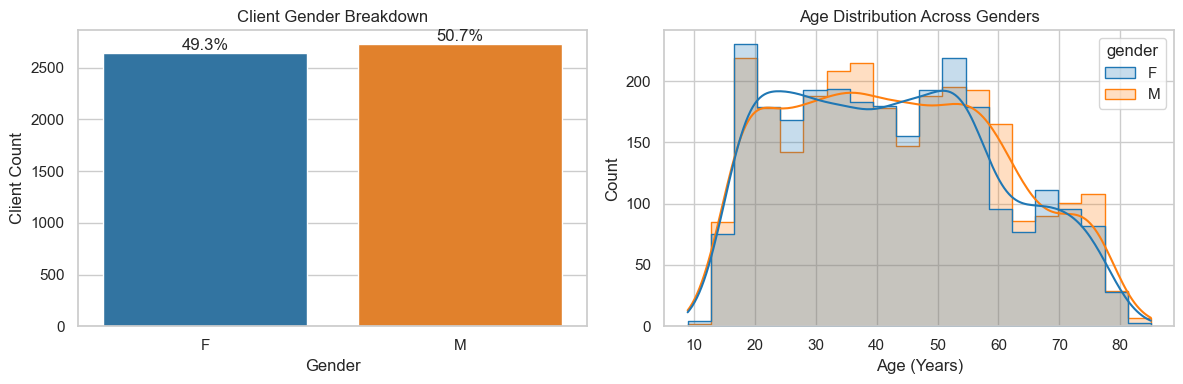

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 1. Gender Distribution
sns.countplot(
    data=client, x="gender", palette=["#1f77b4", "#ff7f0e"], ax=axes[0]
)
axes[0].set_title("Client Gender Breakdown")
axes[0].set_xlabel("Gender")
axes[0].set_ylabel("Client Count")

# Add percentage labels
total = len(client)
for p in axes[0].patches:
  pct = f"{100 * p.get_height() / total:.1f}%"
  axes[0].annotate(
      pct,
      (p.get_x() + p.get_width() / 2.0, p.get_height()),
      ha="center",
      va="bottom",
  )

# 2. Age Distribution by Gender
sns.histplot(
    data=client,
    x="age",
    hue="gender",
    element="step",
    bins=20,
    kde=True,
    palette=["#1f77b4", "#ff7f0e"],
    ax=axes[1],
)
axes[1].set_title("Age Distribution Across Genders")
axes[1].set_xlabel("Age (Years)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

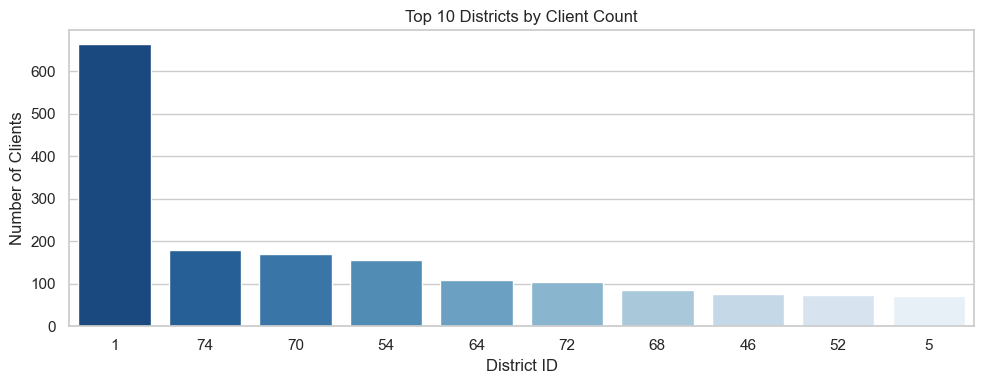

In [7]:
plt.figure(figsize=(10, 4))
top_districts = client["district_id"].value_counts().head(10)
sns.barplot(
    x=top_districts.index,
    y=top_districts.values,
    palette="Blues_r",
    order=top_districts.index,
)
plt.title("Top 10 Districts by Client Count")
plt.xlabel("District ID")
plt.ylabel("Number of Clients")
plt.tight_layout()
plt.show()

## ooo  

In [8]:
import os
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

# 1. Load clean datasets
loans = pd.read_csv('../cleanData/clean_loan.csv', sep=';')
clients = pd.read_csv('../cleanData/clean_client.csv', sep=';')
disp = pd.read_csv('../cleanData/clean_disp.csv', sep=';')

# Standardize keys as strings
loans['account_id'] = loans['account_id'].astype(str)
loans['loan_id'] = loans['loan_id'].astype(str)
disp['account_id'] = disp['account_id'].astype(str)
disp['client_id'] = disp['client_id'].astype(str)
clients['client_id'] = clients['client_id'].astype(str)

# 2. Filter for primary account OWNER (the true borrower)
owner_disp = disp[disp['type'].str.upper() == 'OWNER'][['account_id', 'client_id']]



# 3. Check for multi-signers / co-disponents (potential risk signal)
co_disponents = disp[disp['type'].str.upper() == 'DISPONENT'].groupby('account_id')['client_id'].count()
co_disponents.name = 'has_co_signer'

# 4. Merge owner client details
client_owners = owner_disp.merge(clients, on='client_id', how='left')
client_owners = client_owners.merge(co_disponents, on='account_id', how='left')
client_owners['has_co_signer'] = client_owners['has_co_signer'].fillna(0).astype(int)

# 5. Merge with loans to calculate age at the time of loan issuance (temporal accuracy)
loans['loan_date'] = pd.to_datetime(loans['date'])
if 'birth_date' in client_owners.columns:
    client_owners['birth_date'] = pd.to_datetime(client_owners['birth_date'])
    loan_clients = loans.merge(client_owners, on='account_id', how='left')
    loan_clients['age_at_loan'] = (loan_clients['loan_date'] - loan_clients['birth_date']).dt.days // 365.25
else:
    # If age is already pre-computed in clean_client
    loan_clients = loans.merge(client_owners, on='account_id', how='left')

# 1. Clean string values and generate binary indicators
gender_clean = loan_clients['gender'].astype(str).str.upper().str.strip()

loan_clients['is_male'] = (gender_clean == 'M').astype(int)
loan_clients['is_female'] = (gender_clean == 'F').astype(int)

# Verify counts match
print("--- Gender Counts ---")
print(f"Male count:   {loan_clients['is_male'].sum()}")
print(f"Female count: {loan_clients['is_female'].sum()}")
print(f"Total:        {len(loan_clients)}")

# 6. Encode gender if present
if 'gender' in loan_clients.columns:
    loan_clients['is_male'] = (loan_clients['gender'].str.upper() == 'M').astype(int)

loan_clients.head()

--- Gender Counts ---
Male count:   334
Female count: 348
Total:        682


,loan_id,account_id,date,amount,duration,payments,status,target,is_closed,loan_date,client_id,district_id,birth_number,gender,age,has_co_signer,is_male,is_female
0,5314,1787,1993-07-05,96396.0,12,8033.0,B,1,1,1993-07-05,2166,30,22-07-1947,F,49,0,0,1
1,5316,1801,1993-07-11,165960.0,36,4610.0,A,0,1,1993-07-11,2181,46,22-07-1968,M,28,0,1,0
2,6863,9188,1993-07-28,127080.0,60,2118.0,A,0,1,1993-07-28,11314,45,02-06-1936,M,60,0,1,0
3,5325,1843,1993-08-03,105804.0,36,2939.0,A,0,1,1993-08-03,2235,14,20-04-1940,F,56,0,0,1
4,7240,11013,1993-09-06,274740.0,60,4579.0,A,0,1,1993-09-06,13539,63,07-09-1978,M,18,0,1,0


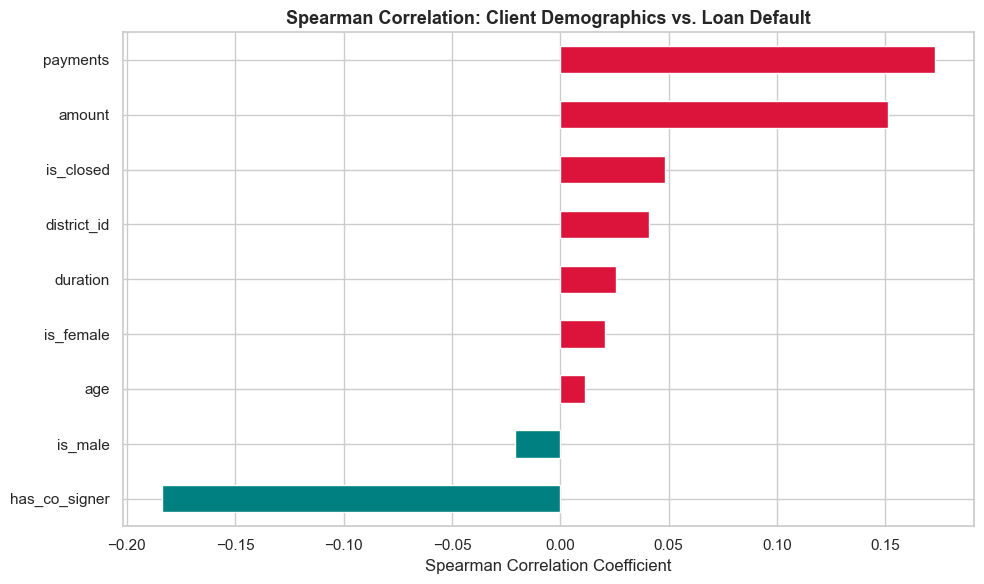


--- Exact Correlation Values ---
has_co_signer   -0.184021
is_male         -0.020693
age              0.011601
is_female        0.020693
duration         0.025705
district_id      0.041030
is_closed        0.048327
amount           0.151322
payments         0.173014
target           1.000000
Name: target, dtype: float64


In [9]:
# 1. Isolate numeric columns for correlation analysis
numeric_cols = loan_clients.select_dtypes(include=[np.number]).columns

# 2. Compute Spearman rank correlation against target
client_corr = loan_clients[numeric_cols].corr(method='spearman')['target'].sort_values()

# 3. Plot horizontal bar chart (excluding the target itself)
plt.figure(figsize=(10, 6))
client_corr.drop('target', errors='ignore').plot(
    kind='barh',
    color=np.where(client_corr.drop('target', errors='ignore') > 0, 'crimson', 'teal')
)
plt.title('Spearman Correlation: Client Demographics vs. Loan Default', fontsize=13, fontweight='bold')
plt.xlabel('Spearman Correlation Coefficient')
plt.tight_layout()
plt.show()

# 4. Print exact correlation values
print("\n--- Exact Correlation Values ---")
print(client_corr)

In [10]:
# 1. Default breakdown by Gender Category
gender_crosstab = pd.crosstab(
    loan_clients['gender'], 
    loan_clients['target'], 
    normalize='index'
) * 100

gender_counts = pd.crosstab(loan_clients['gender'], loan_clients['target'])

print("--- Default Percentage Breakdown by Gender (%) ---")
print(gender_crosstab.round(2).rename(columns={0: 'Good (%) [0]', 1: 'Default (%) [1]'}))

print("\n--- Raw Counts by Gender ---")
print(gender_counts.rename(columns={0: 'Good [0]', 1: 'Default [1]'}))

# 2. Default breakdown by is_male
print("\n--- Target Breakdown by is_male (%) ---")
print(
    (pd.crosstab(loan_clients['is_male'], loan_clients['target'], normalize='index') * 100)
    .round(2)
    .rename(index={0: 'Not Male (Female)', 1: 'Male'}, columns={0: 'Good (%)', 1: 'Default (%)'})
)

# 3. Default breakdown by is_female
print("\n--- Target Breakdown by is_female (%) ---")
print(
    (pd.crosstab(loan_clients['is_female'], loan_clients['target'], normalize='index') * 100)
    .round(2)
    .rename(index={0: 'Not Female (Male)', 1: 'Female'}, columns={0: 'Good (%)', 1: 'Default (%)'})
)

--- Default Percentage Breakdown by Gender (%) ---
target  Good (%) [0]  Default (%) [1]
gender                               
F              88.22            11.78
M              89.52            10.48

--- Raw Counts by Gender ---
target  Good [0]  Default [1]
gender                       
F            307           41
M            299           35

--- Target Breakdown by is_male (%) ---
target             Good (%)  Default (%)
is_male                                 
Not Male (Female)     88.22        11.78
Male                  89.52        10.48

--- Target Breakdown by is_female (%) ---
target             Good (%)  Default (%)
is_female                               
Not Female (Male)     89.52        10.48
Female                88.22        11.78


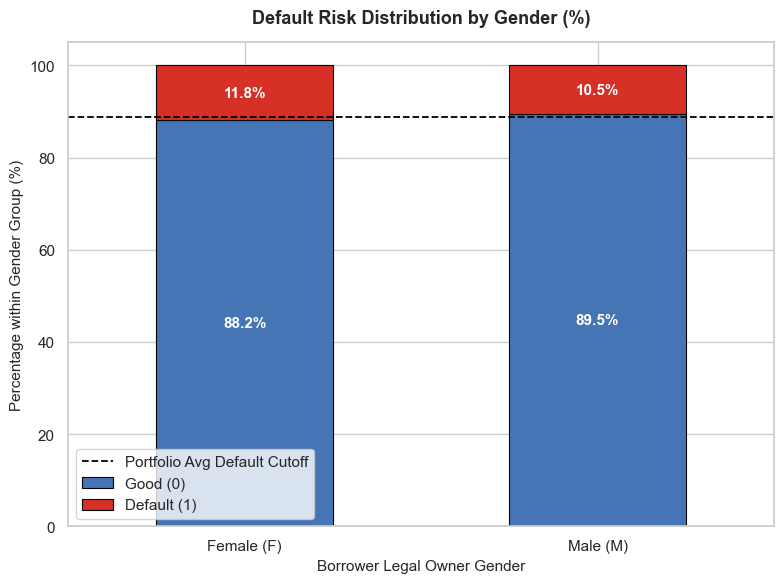

In [11]:
# ---------------------------------------------------------
# Relative Default Risk Distribution by Gender (%)
# ---------------------------------------------------------
# 1. Calculate relative proportions and overall baseline
gender_ct = pd.crosstab(
    loan_clients['gender'], 
    loan_clients['target'], 
    normalize='index'
) * 100

overall_default_rate = (loan_clients['target'].mean()) * 100

# 2. Setup clean single-panel figure
plt.figure(figsize=(8, 6))
ax = plt.gca()

colors_stacked = ['#4575b4', '#d73027']  # Muted Blue (Good), Coral Red (Default)
gender_ct.plot(
    kind='bar',
    stacked=True,
    color=colors_stacked,
    ax=ax,
    edgecolor='black',
    linewidth=0.8
)

plt.title('Default Risk Distribution by Gender (%)', fontsize=13, fontweight='bold', pad=14)
plt.ylabel('Percentage within Gender Group (%)', fontsize=11)
plt.xlabel('Borrower Legal Owner Gender', fontsize=11)
plt.xticks(ticks=[0, 1], labels=['Female (F)', 'Male (M)'], rotation=0, fontsize=11)
plt.ylim(0, 105)

# Add dashed benchmark line for overall baseline portfolio default rate
plt.axhline(
    100 - overall_default_rate, 
    color='black', 
    linestyle='--', 
    linewidth=1.3, 
    label=f'Portfolio Boundary (Avg Default: {overall_default_rate:.1f}%)'
)
plt.legend(['Portfolio Avg Default Cutoff', 'Good (0)', 'Default (1)'], loc='lower left', frameon=True)

# Annotate exact percentages inside the segments
for n, c in enumerate(gender_ct.index):
    good_pct = gender_ct.loc[c, 0]
    def_pct = gender_ct.loc[c, 1]
    
    # Label Good (bottom segment)
    ax.text(
        n, good_pct / 2, f"{good_pct:.1f}%", 
        ha='center', va='center', color='white', fontweight='bold', fontsize=11
    )
    # Label Default (top segment)
    ax.text(
        n, good_pct + (def_pct / 2), f"{def_pct:.1f}%", 
        ha='center', va='center', color='white', fontweight='bold', fontsize=11
    )

plt.tight_layout()
plt.show()

In [12]:
loan_clients.columns

Index(['loan_id', 'account_id', 'date', 'amount', 'duration', 'payments',
       'status', 'target', 'is_closed', 'loan_date', 'client_id',
       'district_id', 'birth_number', 'gender', 'age', 'has_co_signer',
       'is_male', 'is_female'],
      dtype='object')

In [14]:
import os
import pandas as pd

# ==========================================
# CONFIGURATION (Update this for each notebook)
# ==========================================
# Example names: 'features_loan.csv', 'features_district.csv', 
#                'features_orders.csv', 'features_transaction.csv'
OUTPUT_FILENAME = "feature_client.csv"

# List the specific columns you want in your final feature matrix.
# Set to None if your dataframe is already cleaned and contains ONLY features (+ target if in loan notebook)
FEATURE_COLS = ['has_co_signer']  # e.g., ['amount', 'duration', 'payments', 'target']

# ==========================================
# EXPORT LOGIC
# ==========================================
df_export = loan_clients.copy()

# 1. Standardize loan_id as the primary key index
if "loan_id" in df_export.columns:
    df_export["loan_id"] = df_export["loan_id"].astype(str)
    df_export.set_index("loan_id", inplace=True)
elif df_export.index.name != "loan_id":
    df_export.index = df_export.index.astype(str)
    df_export.index.name = "loan_id"

# 2. Filter features if a column list is specified
if FEATURE_COLS is not None:
    valid_cols = [c for c in FEATURE_COLS if c in df_export.columns]
    df_export = df_export[valid_cols]

# 3. Ensure the destination directory exists
output_dir = "../modelData"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, OUTPUT_FILENAME)

# 4. Save to CSV
df_export.to_csv(output_path)

# 5. Validation printout
print("=" * 45)
print(f" Saved successfully to: {output_path}")
print(f" Total Rows (Loans):   {df_export.shape[0]}")
print(f" Total Feature Cols:   {df_export.shape[1]}")
print(f" Missing Values (NaN): {df_export.isna().sum().sum()}")
print("=" * 45)

 Saved successfully to: ../modelData\feature_client.csv
 Total Rows (Loans):   682
 Total Feature Cols:   1
 Missing Values (NaN): 0
